In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

In [2]:
# Load raw dataset
file_path = "flooddata.csv"
df = pd.read_csv(file_path)

In [3]:
df.shape

(20544, 19)

In [4]:
df.columns

Index(['Sl', 'Station_Names', 'Year', 'Month', 'Max_Temp', 'Min_Temp',
       'Rainfall', 'Relative_Humidity', 'Wind_Speed', 'Cloud_Coverage',
       'Bright_Sunshine', 'Station_Number', 'X_COR', 'Y_COR', 'LATITUDE',
       'LONGITUDE', 'ALT', 'Period', 'Flood?'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20544 entries, 0 to 20543
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sl                 20544 non-null  int64  
 1   Station_Names      20544 non-null  object 
 2   Year               20544 non-null  int64  
 3   Month              20544 non-null  int64  
 4   Max_Temp           20544 non-null  float64
 5   Min_Temp           20544 non-null  float64
 6   Rainfall           20544 non-null  float64
 7   Relative_Humidity  20544 non-null  float64
 8   Wind_Speed         20544 non-null  float64
 9   Cloud_Coverage     20544 non-null  float64
 10  Bright_Sunshine    20544 non-null  float64
 11  Station_Number     20544 non-null  int64  
 12  X_COR              20544 non-null  float64
 13  Y_COR              20544 non-null  float64
 14  LATITUDE           20544 non-null  float64
 15  LONGITUDE          20544 non-null  float64
 16  ALT                205

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl,20544.0,10271.500000,5930.686301,0.00,5135.750000,10271.50,15407.2500,20543.00
Year,20544.0,1985.332944,17.610799,1948.00,1972.000000,1987.00,2000.0000,2013.00
Month,20544.0,6.500000,3.452137,1.00,3.750000,6.50,9.2500,12.00
Max_Temp,20544.0,33.450739,2.956401,21.60,31.700000,33.90,35.4000,44.00
Min_Temp,20544.0,21.166872,4.949587,6.20,16.900000,23.40,25.4000,28.10
Rainfall,20544.0,198.776621,240.693197,0.00,8.000000,111.00,312.0000,2072.00
Relative_Humidity,20544.0,79.497375,7.667925,34.00,75.000000,81.00,85.0000,97.00
Wind_Speed,20544.0,1.415049,1.042454,0.00,0.700000,1.20,1.9000,11.20
Cloud_Coverage,20544.0,3.485827,2.083791,0.00,1.600000,3.30,5.5000,7.90
Bright_Sunshine,20544.0,6.419056,1.747959,0.00,4.965517,6.80,7.8000,11.00


In [7]:
df.isna().sum()

Sl                       0
Station_Names            0
Year                     0
Month                    0
Max_Temp                 0
Min_Temp                 0
Rainfall                 0
Relative_Humidity        0
Wind_Speed               0
Cloud_Coverage           0
Bright_Sunshine          0
Station_Number           0
X_COR                    0
Y_COR                    0
LATITUDE                 0
LONGITUDE                0
ALT                      0
Period                   0
Flood?               16051
dtype: int64

In [8]:
column_name = 'Flood?'

# Replace whitespace/empty cells with 0
df[column_name] = df[column_name].replace(r'^\s*$', 0, regex=True)

# Replace NaN with 0
df[column_name] = df[column_name].fillna(0)

# Result checking
print(df[column_name].head())

print(f"✅ All empty/whitespace/null values in '{column_name}' replaced with 0.")


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Flood?, dtype: float64
✅ All empty/whitespace/null values in 'Flood?' replaced with 0.


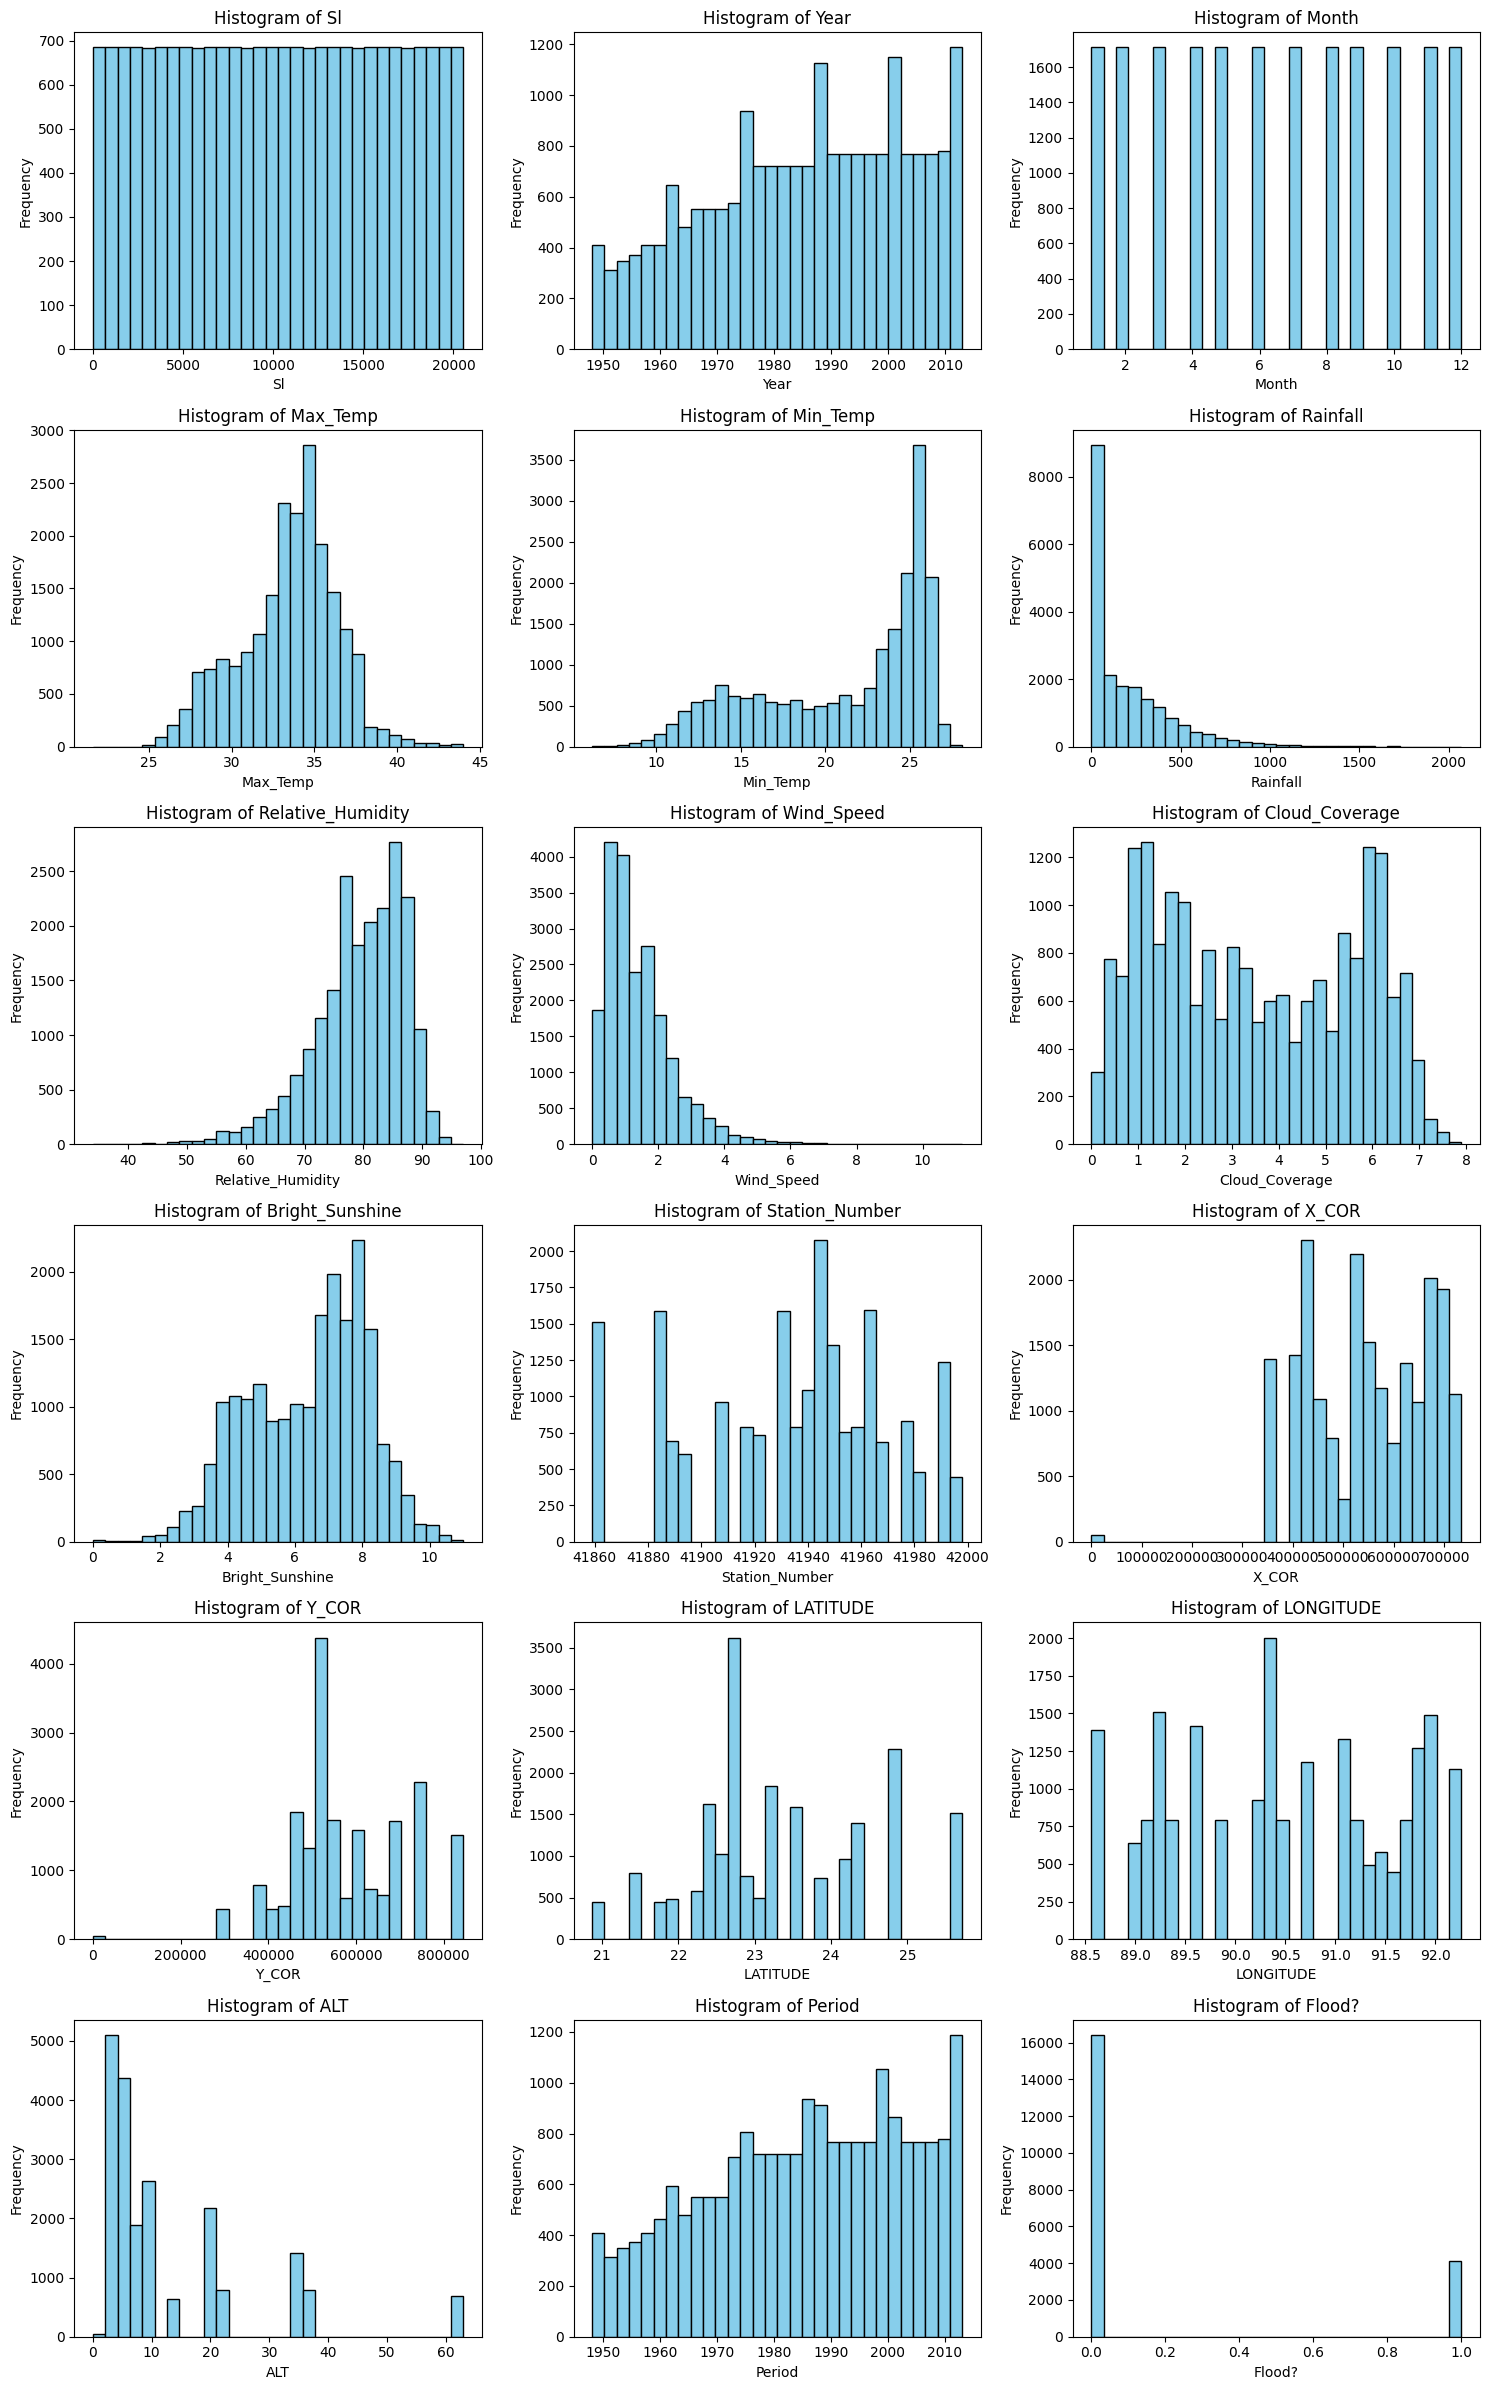

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your dataset is loaded into a dataframe called df
# For example:
# df = pd.read_csv('your_flood_data.csv')

# Select numerical columns only
numerical_cols = df.select_dtypes(include=['number']).columns

# Set up the plot grid size dynamically based on number of columns
import math
num_cols = len(numerical_cols)
cols = 3  # number of plots per row
rows = math.ceil(num_cols / cols)

plt.figure(figsize=(5*cols, 4*rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


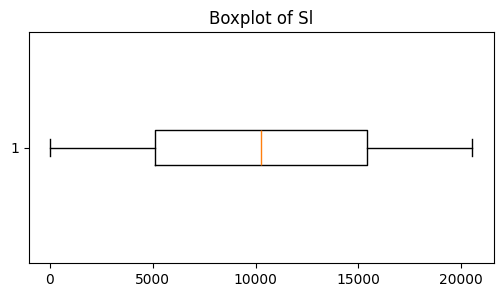

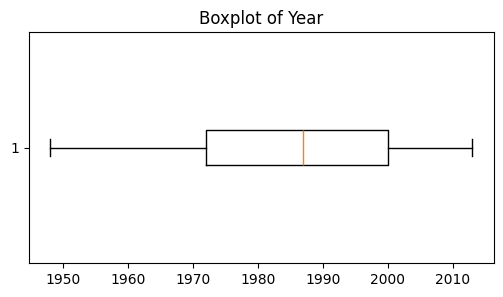

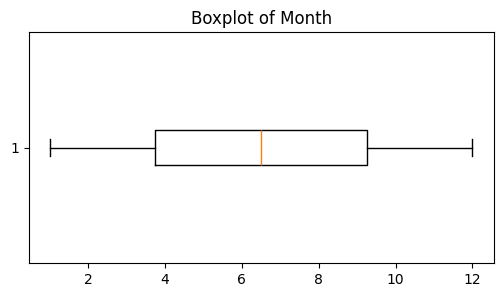

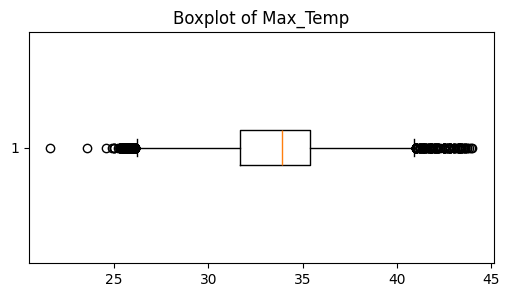

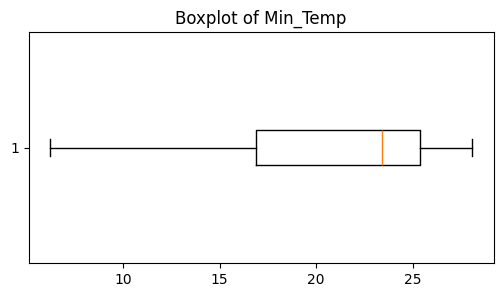

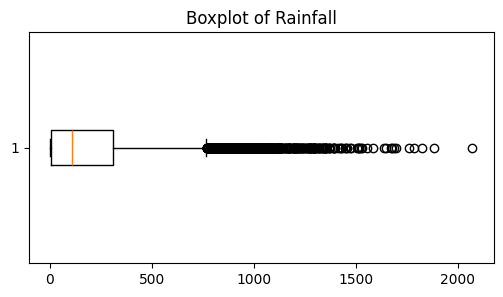

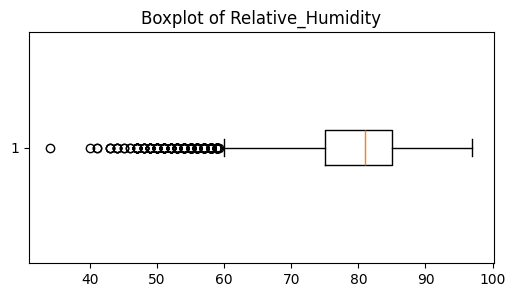

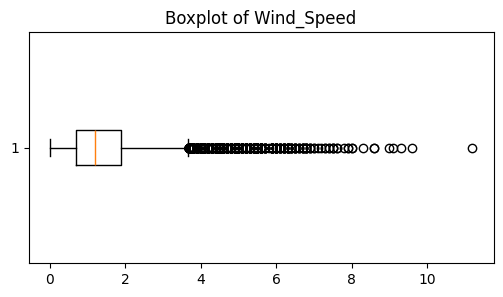

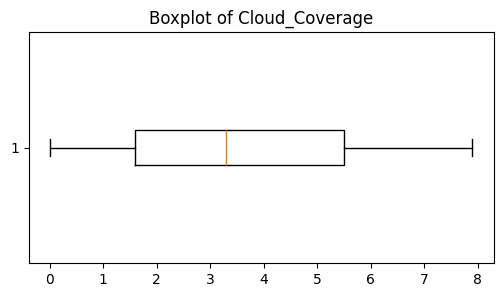

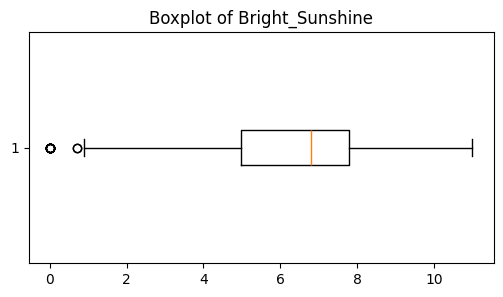

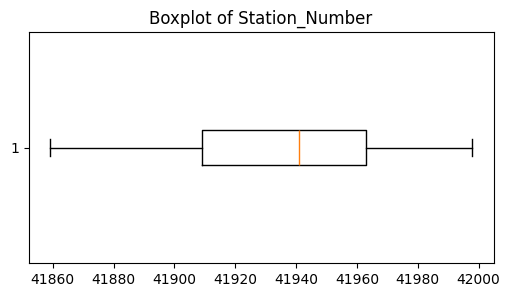

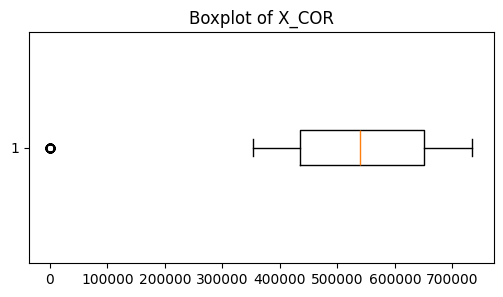

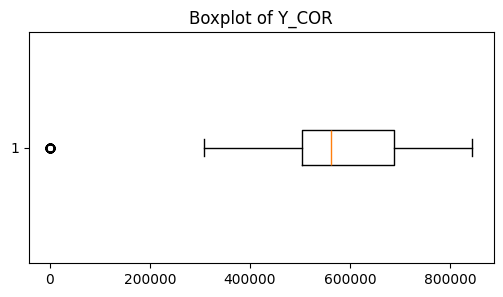

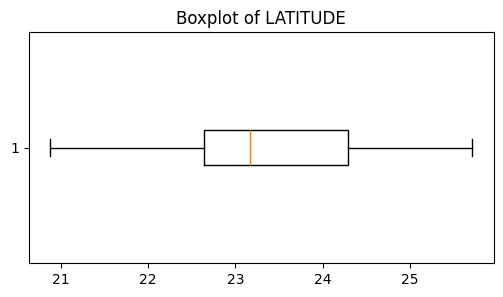

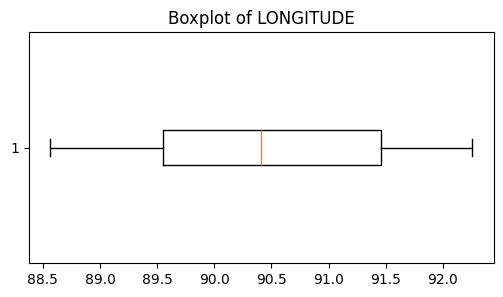

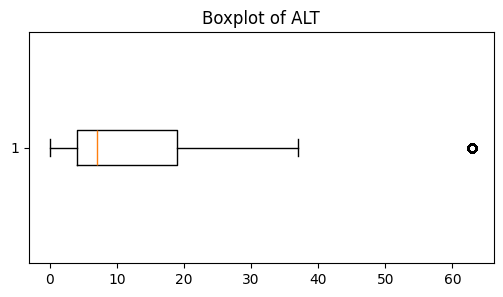

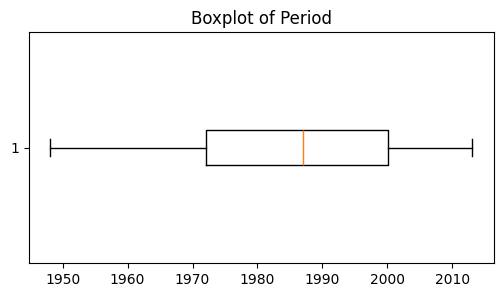

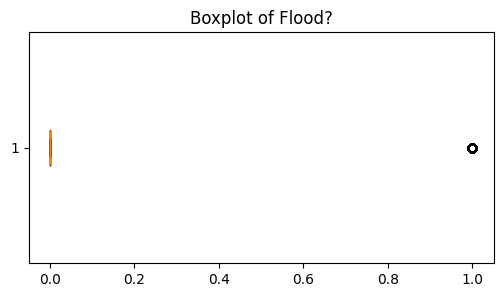

In [10]:
cols = None
if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns
for f in cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[f], vert=False)
    plt.title(f'Boxplot of {f}')
    plt.show()

In [11]:
numerical_cols = df.select_dtypes(include=['number']).columns

def calculate_outlier_percentage(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    percent_outliers = (len(outliers) / len(data)) * 100
    return percent_outliers

outlier_percentages = {}

for col in numerical_cols:
    percent = calculate_outlier_percentage(df, col)
    outlier_percentages[col] = percent
    print(f"{col}: {percent:.2f}% outliers")

# Optionally convert to DataFrame for better display
outlier_df = pd.DataFrame.from_dict(outlier_percentages, orient='index', columns=['% Outliers'])
print(outlier_df)


Sl: 0.00% outliers
Year: 0.00% outliers
Month: 0.00% outliers
Max_Temp: 1.22% outliers
Min_Temp: 0.00% outliers
Rainfall: 3.39% outliers
Relative_Humidity: 1.79% outliers
Wind_Speed: 3.80% outliers
Cloud_Coverage: 0.00% outliers
Bright_Sunshine: 0.07% outliers
Station_Number: 0.00% outliers
X_COR: 0.23% outliers
Y_COR: 0.23% outliers
LATITUDE: 0.00% outliers
LONGITUDE: 0.00% outliers
ALT: 3.33% outliers
Period: 0.00% outliers
Flood?: 20.11% outliers
                   % Outliers
Sl                   0.000000
Year                 0.000000
Month                0.000000
Max_Temp             1.216900
Min_Temp             0.000000
Rainfall             3.392718
Relative_Humidity    1.791277
Wind_Speed           3.801597
Cloud_Coverage       0.000000
Bright_Sunshine      0.068146
Station_Number       0.000000
X_COR                0.233645
Y_COR                0.233645
LATITUDE             0.000000
LONGITUDE            0.000000
ALT                  3.329439
Period               0.000000
Flood?

In [12]:
skewness = df[numerical_cols].skew()
print(skewness)


Sl                   0.000000
Year                -0.275042
Month                0.000000
Max_Temp            -0.283687
Min_Temp            -0.720396
Rainfall             1.751037
Relative_Humidity   -0.961017
Wind_Speed           1.645965
Cloud_Coverage       0.106944
Bright_Sunshine     -0.335069
Station_Number      -0.417021
X_COR               -0.269619
Y_COR                0.159161
LATITUDE             0.360552
LONGITUDE           -0.066932
ALT                  1.998938
Period              -0.275041
Flood?               1.491314
dtype: float64


In [13]:
for col in ['Max_Temp','Rainfall','Relative_Humidity','Wind_Speed','ALT']:
    lower, upper = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower, upper)


In [14]:
numerical_cols = df.select_dtypes(include=['number']).columns

def calculate_outlier_percentage(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    percent_outliers = (len(outliers) / len(data)) * 100
    return percent_outliers

outlier_percentages = {}

for col in numerical_cols:
    percent = calculate_outlier_percentage(df, col)
    outlier_percentages[col] = percent
    print(f"{col}: {percent:.2f}% outliers")

# Optionally convert to DataFrame for better display
outlier_df = pd.DataFrame.from_dict(outlier_percentages, orient='index', columns=['% Outliers'])
print(outlier_df)


Sl: 0.00% outliers
Year: 0.00% outliers
Month: 0.00% outliers
Max_Temp: 0.00% outliers
Min_Temp: 0.00% outliers
Rainfall: 3.39% outliers
Relative_Humidity: 1.79% outliers
Wind_Speed: 3.80% outliers
Cloud_Coverage: 0.00% outliers
Bright_Sunshine: 0.07% outliers
Station_Number: 0.00% outliers
X_COR: 0.23% outliers
Y_COR: 0.23% outliers
LATITUDE: 0.00% outliers
LONGITUDE: 0.00% outliers
ALT: 3.33% outliers
Period: 0.00% outliers
Flood?: 20.11% outliers
                   % Outliers
Sl                   0.000000
Year                 0.000000
Month                0.000000
Max_Temp             0.000000
Min_Temp             0.000000
Rainfall             3.392718
Relative_Humidity    1.791277
Wind_Speed           3.801597
Cloud_Coverage       0.000000
Bright_Sunshine      0.068146
Station_Number       0.000000
X_COR                0.233645
Y_COR                0.233645
LATITUDE             0.000000
LONGITUDE            0.000000
ALT                  3.329439
Period               0.000000
Flood?

In [ ]:
# run 5 times
import pandas as pd

features = ['Max_Temp', 'Rainfall', 'Relative_Humidity', 'Wind_Speed', 'ALT']

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Remaining rows after removing outliers:", len(df))


Remaining rows after removing outliers: 17560


In [22]:
df.shape

(17560, 19)

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl,17560.0,10125.470103,5943.397934,0.00,5095.75,10140.500000,14909.250000,20543.00
Year,17560.0,1985.365604,17.625307,1948.00,1972.00,1987.000000,2000.000000,2013.00
Month,17560.0,6.595387,3.586842,1.00,3.00,7.000000,10.000000,12.00
Max_Temp,17560.0,33.279474,2.947801,26.60,31.40,33.800000,35.400000,40.20
Min_Temp,17560.0,20.840735,5.063146,6.20,16.30,22.900000,25.326316,28.10
Rainfall,17560.0,159.079399,174.187039,0.00,6.00,93.000000,272.000000,671.00
Relative_Humidity,17560.0,79.507959,6.813791,60.00,75.00,81.000000,85.000000,91.00
Wind_Speed,17560.0,1.223913,0.761790,0.10,0.60,1.100000,1.700000,3.30
Cloud_Coverage,17560.0,3.295395,2.024478,0.00,1.40,3.000000,5.300000,7.90
Bright_Sunshine,17560.0,6.535189,1.669501,0.00,5.20,6.885185,7.800000,11.00


In [24]:
numerical_cols = df.select_dtypes(include=['number']).columns

def calculate_outlier_percentage(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    percent_outliers = (len(outliers) / len(data)) * 100
    return percent_outliers

outlier_percentages = {}

for col in numerical_cols:
    percent = calculate_outlier_percentage(df, col)
    outlier_percentages[col] = percent
    print(f"{col}: {percent:.2f}% outliers")

# Optionally convert to DataFrame for better display
outlier_df = pd.DataFrame.from_dict(outlier_percentages, orient='index', columns=['% Outliers'])
print(outlier_df)


Sl: 0.00% outliers
Year: 0.00% outliers
Month: 0.00% outliers
Max_Temp: 0.00% outliers
Min_Temp: 0.00% outliers
Rainfall: 0.00% outliers
Relative_Humidity: 0.00% outliers
Wind_Speed: 0.00% outliers
Cloud_Coverage: 0.00% outliers
Bright_Sunshine: 0.09% outliers
Station_Number: 0.00% outliers
X_COR: 0.13% outliers
Y_COR: 0.13% outliers
LATITUDE: 0.00% outliers
LONGITUDE: 0.00% outliers
ALT: 0.00% outliers
Period: 0.00% outliers
Flood?: 15.63% outliers
                   % Outliers
Sl                   0.000000
Year                 0.000000
Month                0.000000
Max_Temp             0.000000
Min_Temp             0.000000
Rainfall             0.000000
Relative_Humidity    0.000000
Wind_Speed           0.000000
Cloud_Coverage       0.000000
Bright_Sunshine      0.091116
Station_Number       0.000000
X_COR                0.130979
Y_COR                0.130979
LATITUDE             0.000000
LONGITUDE            0.000000
ALT                  0.000000
Period               0.000000
Flood?

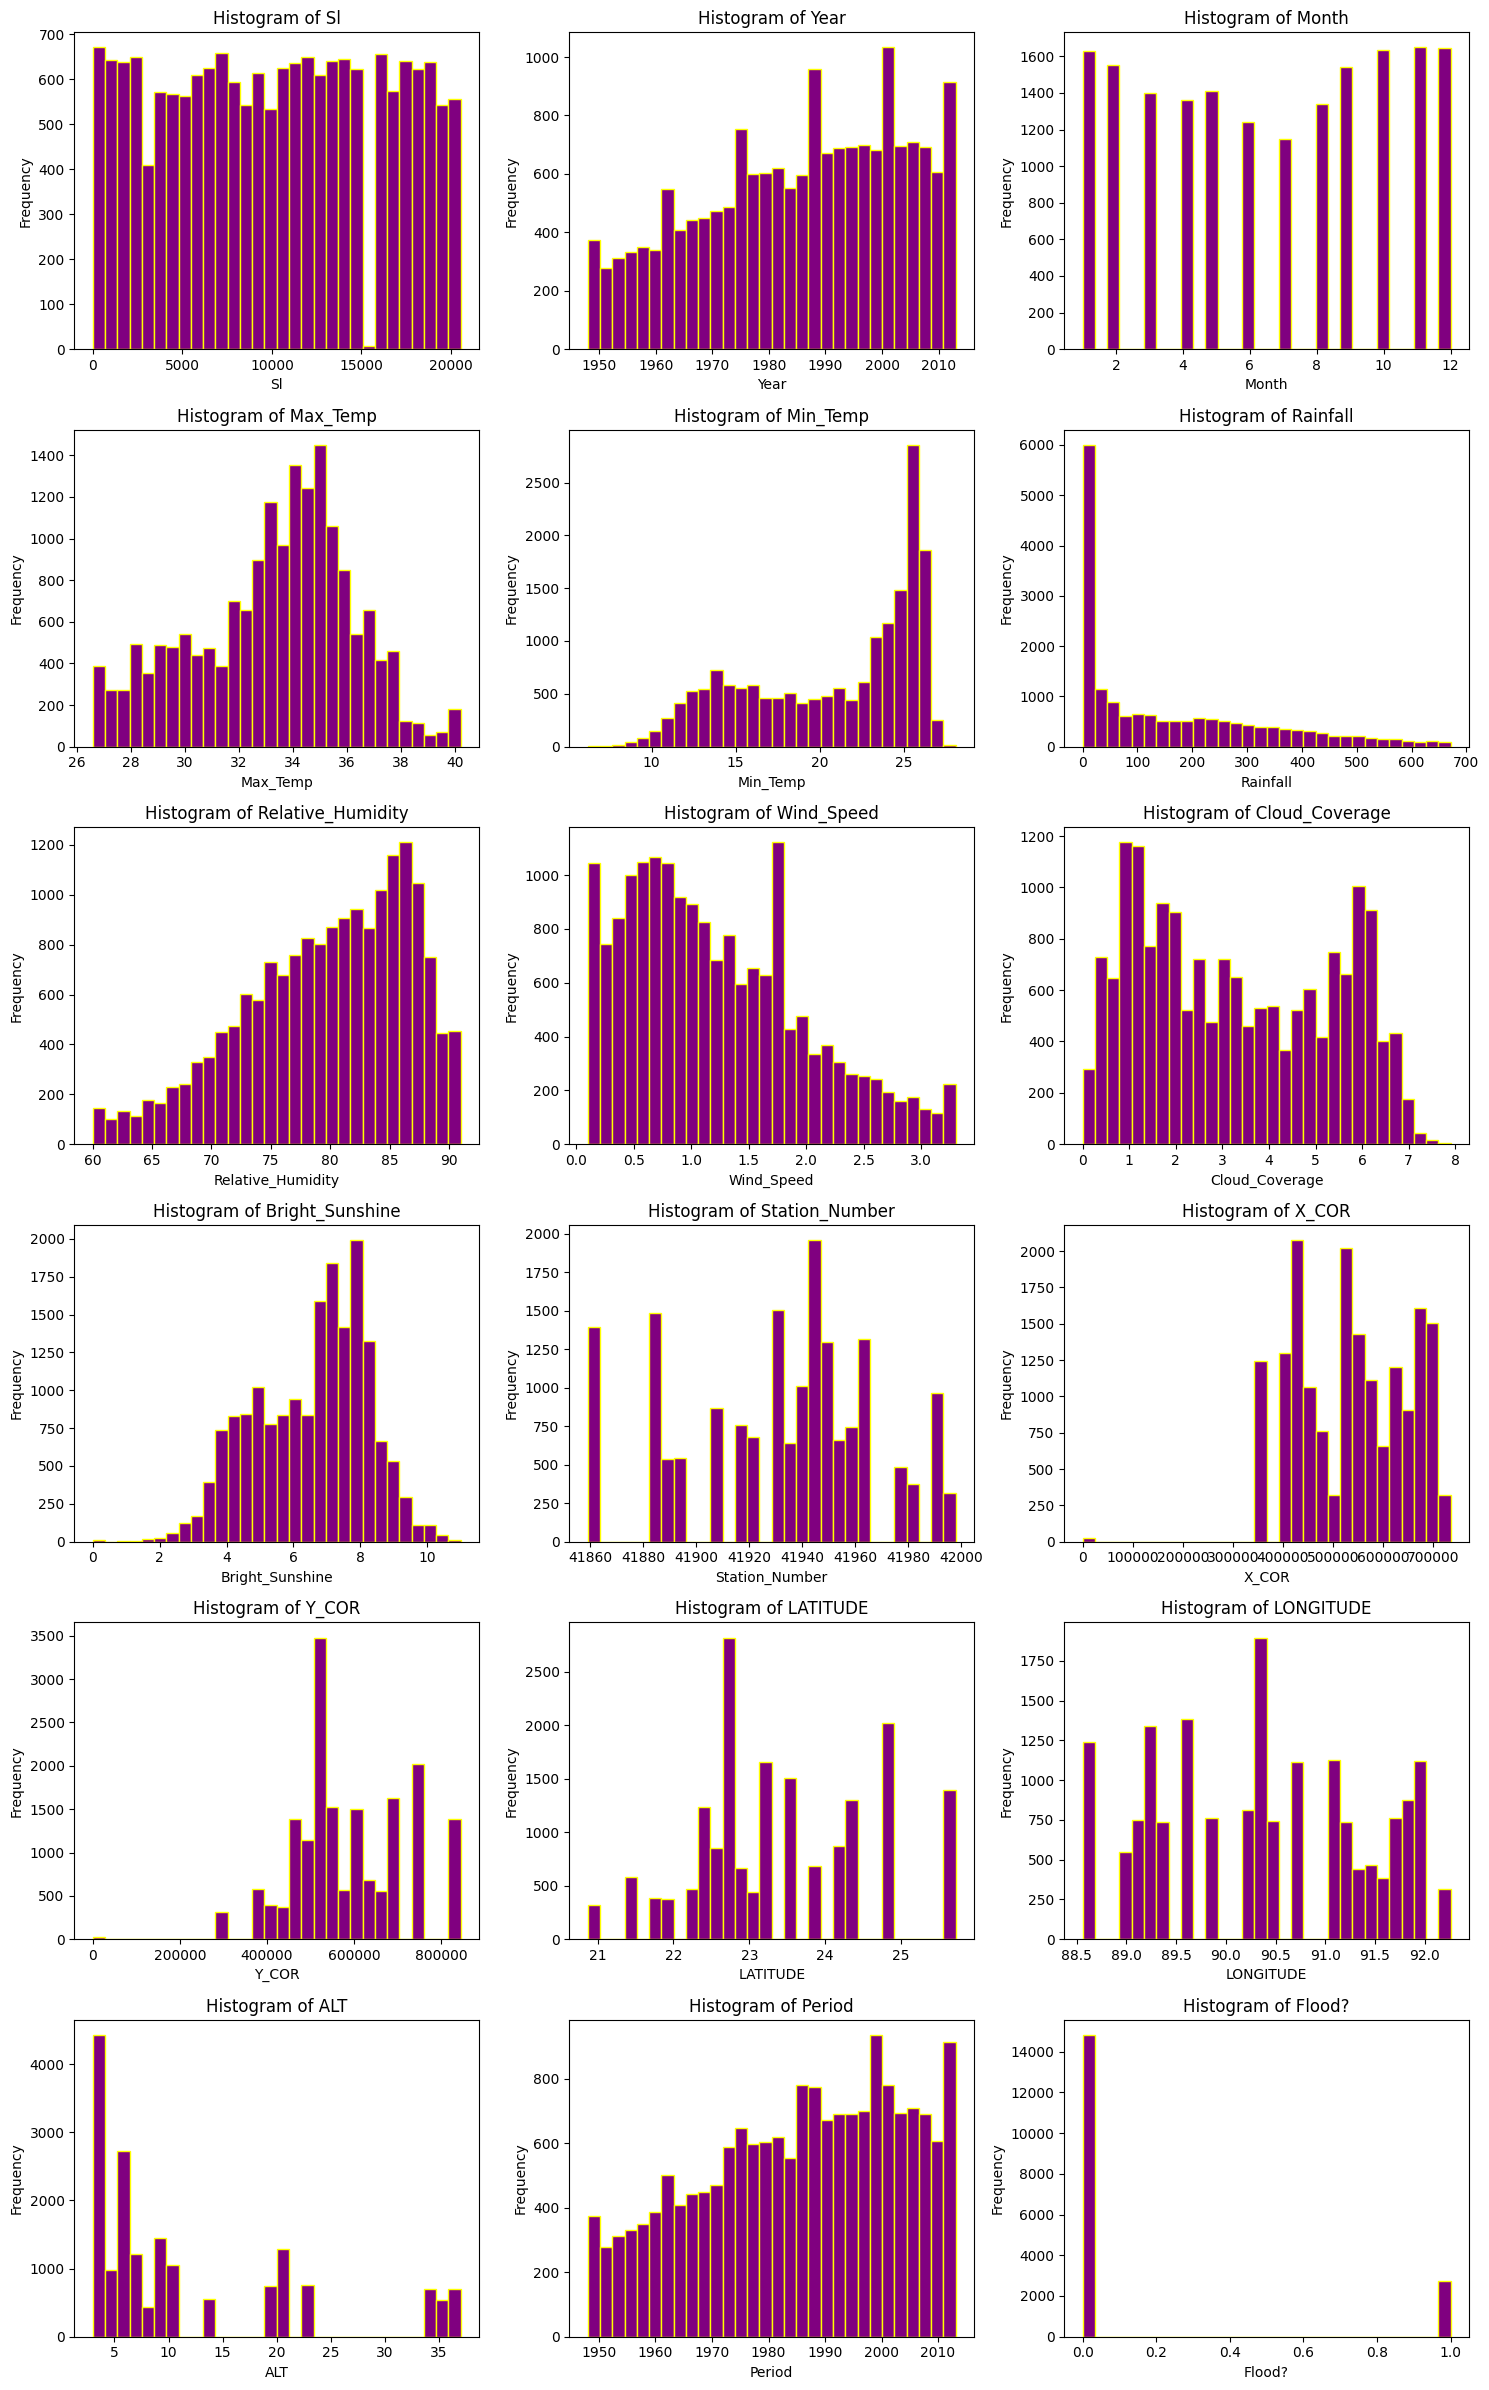

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your dataset is loaded into a dataframe called df
# For example:
# df = pd.read_csv('your_flood_data.csv')

# Select numerical columns only
numerical_cols = df.select_dtypes(include=['number']).columns

# Set up the plot grid size dynamically based on number of columns
import math
num_cols = len(numerical_cols)
cols = 3  # number of plots per row
rows = math.ceil(num_cols / cols)

plt.figure(figsize=(5*cols, 4*rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(df[col].dropna(), bins=30, color='purple', edgecolor='yellow')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [26]:
# As still exist a few percentage of outliers, so we decided to capping again

for col in ['Rainfall','Bright_Sunshine','Wind_Speed']:
    lower, upper = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lower, upper)


In [27]:
numerical_cols = df.select_dtypes(include=['number']).columns

def calculate_outlier_percentage(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    percent_outliers = (len(outliers) / len(data)) * 100
    return percent_outliers

outlier_percentages = {}

for col in numerical_cols:
    percent = calculate_outlier_percentage(df, col)
    outlier_percentages[col] = percent
    print(f"{col}: {percent:.2f}% outliers")

# Optionally convert to DataFrame for better display
outlier_df = pd.DataFrame.from_dict(outlier_percentages, orient='index', columns=['% Outliers'])
print(outlier_df)


Sl: 0.00% outliers
Year: 0.00% outliers
Month: 0.00% outliers
Max_Temp: 0.00% outliers
Min_Temp: 0.00% outliers
Rainfall: 0.00% outliers
Relative_Humidity: 0.00% outliers
Wind_Speed: 0.00% outliers
Cloud_Coverage: 0.00% outliers
Bright_Sunshine: 0.00% outliers
Station_Number: 0.00% outliers
X_COR: 0.13% outliers
Y_COR: 0.13% outliers
LATITUDE: 0.00% outliers
LONGITUDE: 0.00% outliers
ALT: 0.00% outliers
Period: 0.00% outliers
Flood?: 15.63% outliers
                   % Outliers
Sl                   0.000000
Year                 0.000000
Month                0.000000
Max_Temp             0.000000
Min_Temp             0.000000
Rainfall             0.000000
Relative_Humidity    0.000000
Wind_Speed           0.000000
Cloud_Coverage       0.000000
Bright_Sunshine      0.000000
Station_Number       0.000000
X_COR                0.130979
Y_COR                0.130979
LATITUDE             0.000000
LONGITUDE            0.000000
ALT                  0.000000
Period               0.000000
Flood?

In [28]:
# Finally we have the fresh data without outliers.

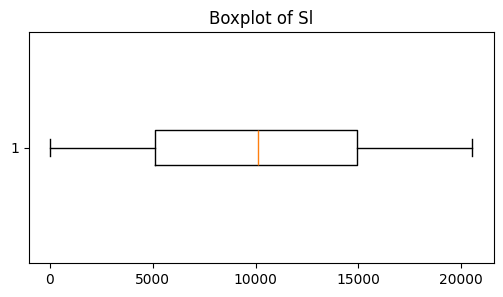

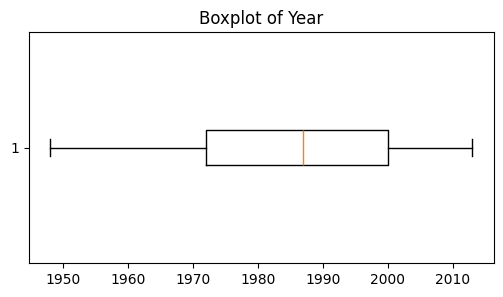

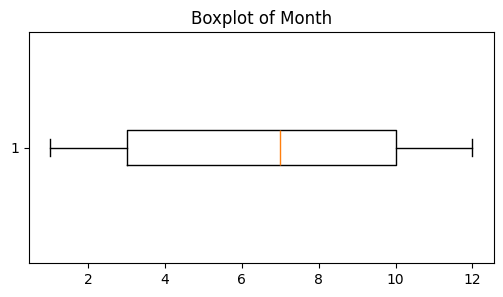

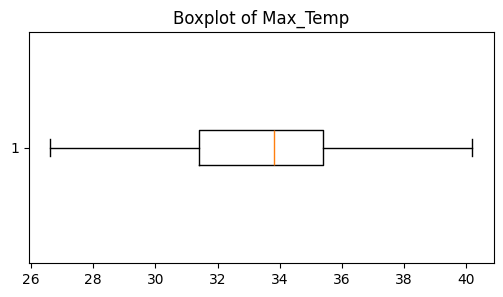

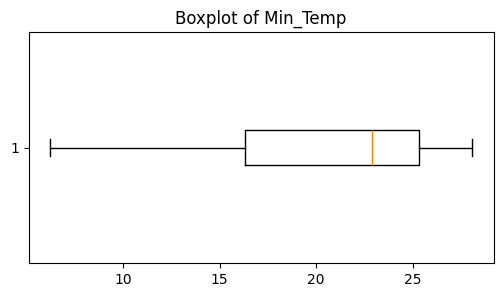

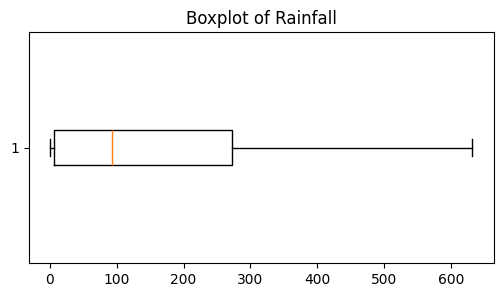

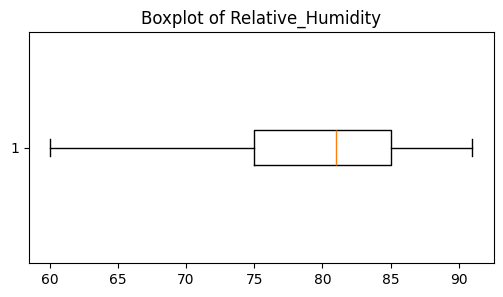

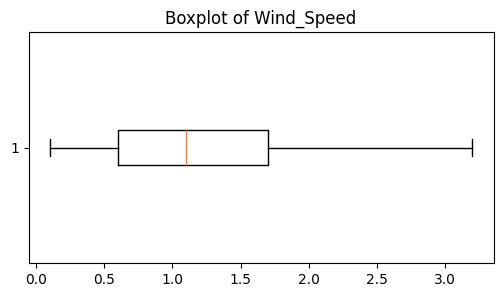

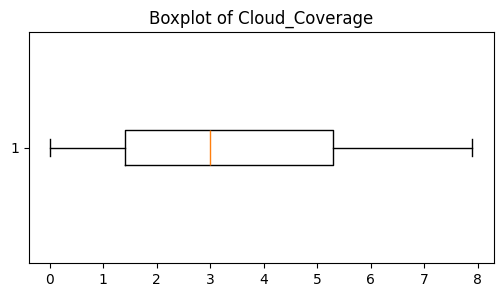

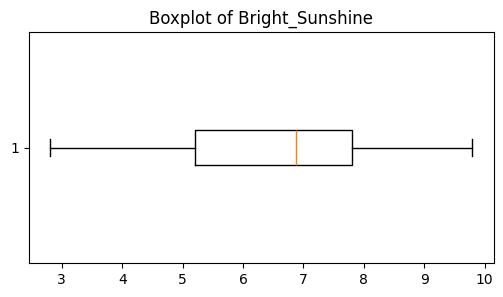

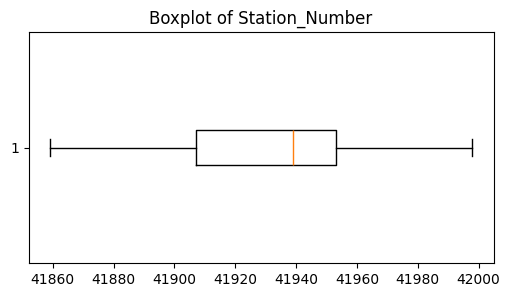

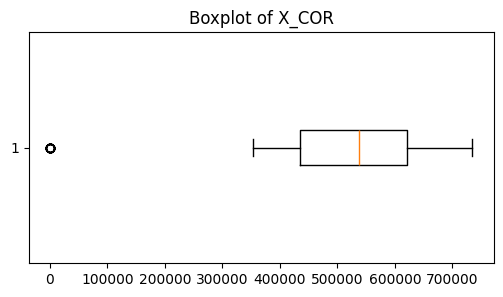

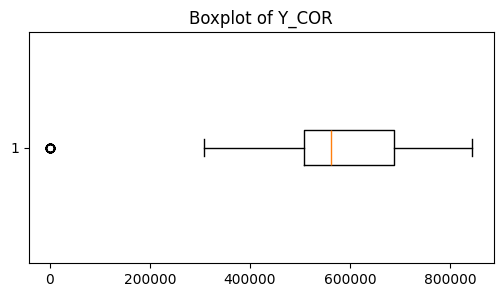

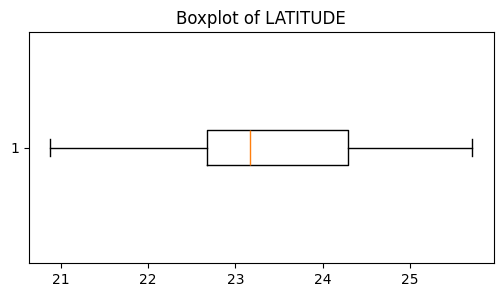

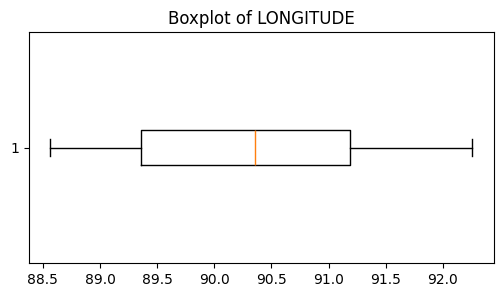

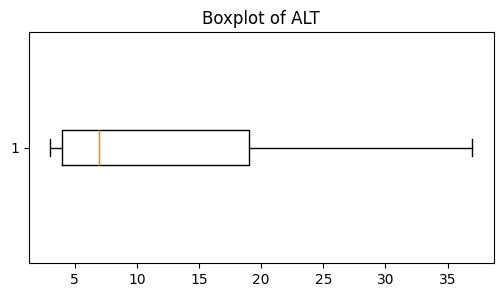

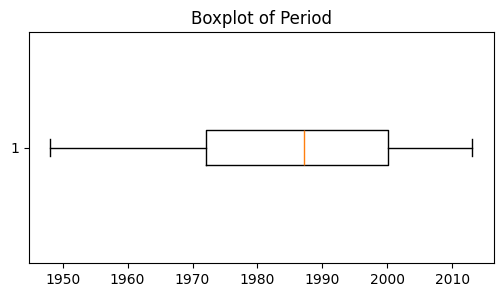

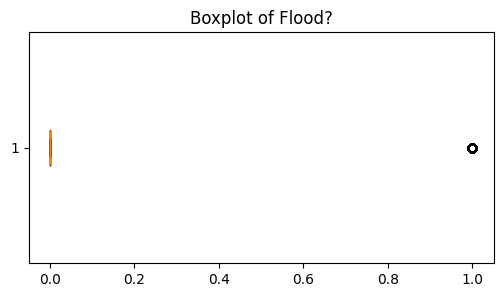

In [29]:
cols = None
if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns
for f in cols:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[f], vert=False)
    plt.title(f'Boxplot of {f}')
    plt.show()

In [30]:
skewness = df[numerical_cols].skew()
print(skewness)


Sl                   0.027332
Year                -0.313985
Month               -0.049169
Max_Temp            -0.343267
Min_Temp            -0.605090
Rainfall             0.971119
Relative_Humidity   -0.592746
Wind_Speed           0.665526
Cloud_Coverage       0.191969
Bright_Sunshine     -0.332450
Station_Number      -0.356602
X_COR               -0.117010
Y_COR                0.187516
LATITUDE             0.309371
LONGITUDE            0.015544
ALT                  1.369540
Period              -0.313973
Flood?               1.892877
dtype: float64


In [31]:
import numpy as np
import pandas as pd

# List of numeric features that are obviously skewed
skewed_features = ['Rainfall', 'Wind_Speed', 'ALT']

# Apply log1p transformation and create new columns
for col in skewed_features:
    new_col = col + ' log'  # new column name
    df[new_col] = np.log1p(df[col])

# Optional: check skewness before and after transformation
for col in skewed_features:
    print(f"{col} original skew: {df[col].skew():.3f}, {col} log skew: {df[col+' log'].skew():.3f}")


Rainfall original skew: 0.971, Rainfall log skew: -0.621
Wind_Speed original skew: 0.666, Wind_Speed log skew: 0.077
ALT original skew: 1.370, ALT log skew: 0.640


In [32]:
df.drop(['Station_Number'], axis=1, inplace=True)


In [33]:
print(df['Station_Names'].nunique())


32


In [35]:
# Suppose your final DataFrame after preprocessing is 'df'
# Save it to a new CSV file

df.to_csv('flood_data_preprocessed.csv', index=False)
